# 🎓 The Academic Predictor: Master Student Workbook
**Student Name:** [Your Name Here]

Welcome to your Final Project! This notebook contains all the requirements for your HSC submission. Work through this notebook sequentially. You must write the Python code yourself based on the lessons we completed in class.

---
### ⚙️ Setup: Library Installation
Run the cell below first to instantly install the required AI libraries.

In [1]:
!pip install --prefer-binary pandas numpy scikit-learn matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

print("\n✅ All libraries successfully installed and imported!")


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip

✅ All libraries successfully installed and imported!


---
## Phase 1: Data Automation
**🎯 The Goal:** You must use Pandas to load `master_markbook.csv` and clean it. Machine Learning algorithms will crash if they encounter missing data (`NaN`). Furthermore, an AI will learn incorrect mathematical patterns if it is trained on impossible data (like scores below 0 or above 100).

**📄 Documentation Task:** Create a new Markdown cell below your code. Add the heading `### Data Cleaning Strategy`. Underneath, explicitly list the three types of "dirty data" you fixed: 1. Missing values, 2. Negative scores, and 3. Scores over 100. Explain why cleaning this is legally and ethically important.

**📊 PPT Slide Task:** Create a slide titled "Data Strategy". Take a screenshot of the raw CSV showing a corrupted row (e.g., someone with -50 or 200). Put it next to a screenshot of your cleaned Pandas dataframe. Add bullet points explaining that "Garbage Data In = Garbage AI Predictions Out."

In [4]:
print("--- Loading and Cleaning Data ---")

# TODO 1: Load the raw dataset into a variable called df_raw (Hint: use encoding='latin-1' to avoid Unicode errors)
df_raw = pd.read_csv("master_markbook.csv", encoding='latin-1')
# TODO 2: Print the length (number of rows) of df_raw so you know your starting number.
print(len(df_raw))
# TODO 3: Create a new variable called df_clean. Use the Pandas .dropna() method to delete any rows with missing data.
df_clean = df_raw.dropna()
# TODO 4: Update df_clean by filtering it. You must only keep rows where 'Maths_Advanced', 'Physics', and 'Software_Engineering_Final' are .between(0, 100).
df_clean = df_clean[
    df_clean['Maths_Advanced'].between(0, 100) &
    df_clean['Physics'].between(0, 100) &
    df_clean['Software_Engineering_Final'].between(0, 100) &
    df_clean['Modern_History'].between(0, 100)
]
# TODO 5: Print the length of df_clean. (You should have fewer rows than you started with!)
print(len(df_clean))

--- Loading and Cleaning Data ---
28
21


---
## Phase 2: The Baseline AI
**🎯 The Goal:** Build a basic AI (Linear Regression) that predicts the final Software Engineering mark using only **one** input subject (Maths_Advanced). You must split your data into Training (80%) and Testing (20%) sets so the AI cannot "cheat" by memorizing the test answers.

**📄 Documentation Task:** Add a Markdown cell below. Write the heading `### The ML Pipeline`. List and define the 5 stages of Machine Learning (Define, Collect, Prepare, Train, Evaluate) in the context of this specific school project.

**📊 PPT Slide Task:** Create a slide titled "The Problem". Introduce your chosen student (Alex, Victor, Yara, or Zane) and explain their missing assessment. Add a graphic showing how you divided the class data into an 80% Training block and a 20% Testing block.

In [28]:
print("--- Training Level 1 AI ---")
from sklearn.metrics import root_mean_squared_error
# TODO 1: Create a variable X1 and set it to df_clean[['Maths_Advanced']].values
X1 = df_clean[['Maths_Advanced']].values
# TODO 2: Create a variable y and set it to df_clean['Software_Engineering_Final'].values
y = df_clean['Software_Engineering_Final'].values
# TODO 3: Use the train_test_split() function to divide X1 and y. Set test_size=0.2 and random_state=42.
X1_train, X1_test, y_train, y_test = train_test_split(
    X1, y, test_size=0.2, random_state=42
)
# TODO 4: Initialize a LinearRegression() model.
model = LinearRegression()
# TODO 5: .fit() your model using the training data only.
model.fit(X1_train, y_train)
# TODO 6: Use your model to .predict() the outcomes for your test data.
y_pred = model.predict(X1_test)
# TODO 7: Calculate the RMSE (Root Mean Squared Error) by comparing your predictions against the real y_test values. Print the result.
rmse = root_mean_squared_error(y_test, y_pred)
print("RMSE:", rmse)

--- Training Level 1 AI ---
RMSE: 4.488049167967769


---
## Phase 3: Mathematical Proof
**🎯 The Goal:** Machine Learning is not magic; it is just geometry. You must extract the specific linear equation ($y = wx + b$) that your AI learned from the dataset and visualize it on a scatter plot.

**📄 Documentation Task:** Create a Markdown cell. Write down the exact mathematical formula your AI generated. (e.g., `Software_Engineering_Final = [Your Weight] * Maths_Advanced + [Your Bias]`). Write a sentence explaining what the weight actually means in plain English (e.g., "For every 1 extra mark a student gets in Maths, their Software score increases by X marks").

**📊 PPT Slide Task:** Create a slide titled "The Mathematical Proof". Insert your generated Matplotlib scatter plot. Point an arrow to the red line and explain to your audience that this line represents the AI's algorithm.

--- Extracting the Formula ---
Formula: y = 1.02x + -1.36


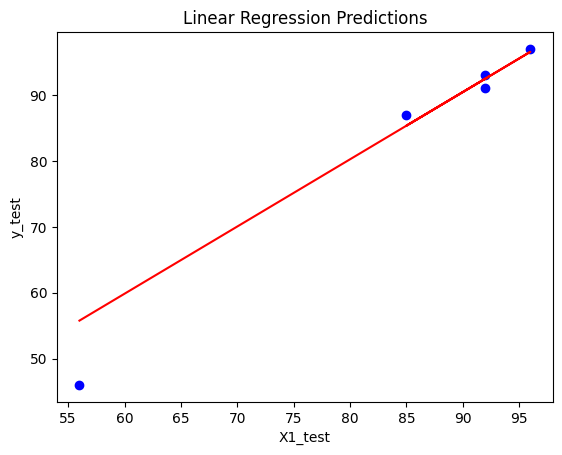

In [29]:
print("--- Extracting the Formula ---")

# TODO 1: Extract the weight using your_model.coef_[0] and the bias using your_model.intercept_
weight = model.coef_[0]
bias = model.intercept_
# TODO 2: Print out the final formula using those two numbers.
print(f"Formula: y = {weight:.2f}x + {bias:.2f}")
# TODO 3: Use plt.scatter() to plot the X1_test data against the y_test data. Make the dots blue.
plt.scatter(X1_test, y_test, color="blue")
# TODO 4: Use plt.plot() to draw a line mapping X1_test against your AI's predictions. Make the line red.
y_predictions = model.predict(X1_test)
plt.plot(X1_test, y_predictions, color="red")
# TODO 5: Add a title, xlabel, ylabel, and plt.show() to display the graph.
plt.title("Linear Regression Predictions")
plt.xlabel("X1_test")
plt.ylabel("y_test")
plt.show()

---
## Phase 4: The Object-Oriented Engine
**🎯 The Goal:** Loose procedural scripts are dangerous in production environments. You must encapsulate your Scikit-Learn algorithm inside a custom Python Class to meet the HSC Object-Oriented Programming (OOP) requirements.

**📄 Documentation Task:** Go to a website like draw.io or Lucidchart. Create a formal UML Class Diagram with a box titled `MarkPredictor`. It must include the attribute `- model: LinearRegression` and the methods `+ fit(X, y)` and `+ predict(X)`. Save it as an image and embed it in a markdown cell below.

**📊 PPT Slide Task:** Create a slide titled "System Architecture". Show your Class Diagram. Explain the concept of "Encapsulation" to the class and state why keeping the model locked inside an object prevents accidental data leaks.

In [8]:
print("--- Training OOP Engine ---")

# TODO 1: Write a class called MarkPredictor.
class MarkPredictor:
# TODO 2: Create an __init__(self) function that initializes self.model = LinearRegression()
    def __init__(self):
        self.model = LinearRegression()
# TODO 3: Create a fit(self, X, y) function that calls self.model.fit(X, y)
    def fit(self, X, y):
        self.model.fit(X, y)
# TODO 4: Create a predict(self, X) function that returns self.model.predict(X)
    def predict(self, X):
        return self.model.predict(X)
# TODO 5: Outside the class, create an instance called my_ai = MarkPredictor()
my_ai = MarkPredictor()

# TODO 6: Train your my_ai object using your X1_train data.
my_ai.fit(X1_train, y_train)
# TODO 7: Generate predictions and print the new RMSE to prove your object works.
y_predictions = my_ai.predict(X1_test)

rmse = np.sqrt(mean_squared_error(y_test, y_predictions))
print("RMSE:", rmse)

--- Training OOP Engine ---
RMSE: 4.488049167967769


---
## Phase 5: Scaling Up to Level 2 (Multi-Subject)
**🎯 The Goal:** To achieve a Band 6, your AI needs to be smarter. You will now feed it two subjects simultaneously (Maths_Advanced and Physics). Because these subjects have different averages and variances, you MUST use `StandardScaler` to align them mathematically.

**📄 Documentation Task:** Write a paragraph explaining "Feature Scaling". Explain that if we don't scale the data, the AI might wrongly prioritize a subject just because the numbers are physically larger (e.g., if one subject was marked out of 500 and another out of 10).

**📊 PPT Slide Task:** Create a slide titled "Level 1 vs Level 2 AI". Put your Level 1 RMSE (single subject) next to your Level 2 RMSE (multi-subject). Explain why the error went down when the AI was given more context.

In [9]:
print("--- Training Level 2 AI (Multi-Subject) ---")

# TODO 1: Create a new variable X2 that extracts BOTH 'Maths_Advanced' and 'Physics' from df_clean.
X2 = df_clean[['Maths_Advanced', 'Physics', 'Modern_History']].values
# TODO 2: Run train_test_split() again, this time using X2 and y.
X2_train, X2_test, y_train, y_test = train_test_split(
    X2, y, test_size=0.2, random_state=42
)
# TODO 3: Initialize a StandardScaler()
scaler = StandardScaler()
# TODO 4: Use .fit_transform() to scale your X2_train data.
X2_train_scaled = scaler.fit_transform(X2_train)
# TODO 5: Use ONLY .transform() to scale your X2_test data. (Do not fit on test data!)
X2_test_scaled = scaler.transform(X2_test)
# TODO 6: Create a new MarkPredictor() object.
my_ai_level2 = MarkPredictor()
# TODO 7: Train it on the scaled X2_train data.
my_ai_level2.fit(X2_train_scaled, y_train)
# TODO 8: Predict on the scaled X2_test data and print the final Level 2 RMSE.
y_predictions = my_ai_level2.predict(X2_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_predictions))
print("Level 2 RMSE:", rmse)

--- Training Level 2 AI (Multi-Subject) ---
Level 2 RMSE: 4.960194332209407


---
## Phase 6: The Ethics Audit (The 80% Rule)
**🎯 The Goal:** We must ensure our AI does not discriminate. You will group students into STEM (Physics > 70) and Humanities (Modern_History > 70) and check if the AI's predictions result in one group failing significantly more than the other.

**📄 Documentation Task:** Write an "Ethics Report" markdown cell. Search Google for the "Robodebt scandal" in Australia. Write a paragraph explaining how blind trust in automated systems causes harm, and justify why schools must always use a "Human-in-the-Loop" to review AI grades.

**📊 PPT Slide Task:** Create a slide titled "Bias & Ethics Audit". Display the pass rate percentages for Group A and Group B, and show your final Disparate Impact Ratio. Based on your results, give your final recommendation for the missing student's score!

In [30]:
print("--- Running Bias Audit (80% Rule) ---")

# TODO 1: Create group_a by filtering df_clean for students with 'Physics' > 70
group_a = df_clean[df_clean['Physics'] > 70]
# TODO 2: Create group_b by filtering df_clean for students with 'Modern_History' > 70
group_b = df_clean[df_clean['Modern_History'] > 70]
# TODO 3: Calculate the pass rate for Group A. (Find the mean of rows where Software_Engineering_Final >= 50)
pass_rate_a = (group_a['Software_Engineering_Final'] >= 50).mean()
print("Group A Pass Rate:", pass_rate_a)
# TODO 4: Calculate the pass rate for Group B in the same way.
pass_rate_b = (group_b['Software_Engineering_Final'] >= 50).mean()
print("Group B Pass Rate:", pass_rate_b)
# TODO 5: Calculate the Disparate Impact Ratio by dividing the Group B pass rate by the Group A pass rate.
disparate_impact_ratio = pass_rate_b / pass_rate_a
print("Disparate Impact Ratio:", disparate_impact_ratio)
# TODO 6: Write an IF statement: If the ratio is less than 0.8, print a WARNING that bias was detected. Else, print that the audit passed.
if disparate_impact_ratio < 0.8:
    print("WARNING: Potential bias detected.")
else:
    print("Audit passed: No bias detected under the 80% rule.")

--- Running Bias Audit (80% Rule) ---
Group A Pass Rate: 1.0
Group B Pass Rate: 0.75
Disparate Impact Ratio: 0.75


---
## Phase 7: Overfitting Check (Cross-Validation)
**🎯 The Goal:** Use K-Fold Cross-Validation to test the AI on 5 completely different slices of the data. This proves the AI hasn't just "memorized" your specific training data.

**📄 Documentation Task:** Define "Overfitting". Explain why an AI that memorizes past data will catastrophically fail when trying to predict marks for next year's Year 12 cohort.

In [ ]:
print("--- Cross-Validation Check ---")

# TODO 1: Scale your entire X2 dataset using fit_transform()
# TODO 2: Use the cross_val_score() function. Pass in a LinearRegression(), your scaled data, and y. Set cv=5 and scoring='neg_root_mean_squared_error'.
# TODO 3: Calculate the mean of the scores (Remember to invert the negative number!)
# TODO 4: Print the Cross-Validation RMSE.

---
## Phase 8: The Logic Gatekeeper
**🎯 The Goal:** Write a procedural safeguard (a hard-coded IF/ELSE function) to block unreliable students from using the AI system entirely.

**📄 Documentation Task:** Draw a Decision Tree flowchart showing how this gatekeeper works. Use a diamond shape for the IF condition (Attendance < 50%), and rectangles for the True/False outcomes. Embed the image below.

In [ ]:
print("--- Logic Gatekeeper ---")

# TODO 1: Define a function called check_data_reliability(attendance_percentage)
# TODO 2: Inside the function, write an IF statement: if attendance is less than 50.0, print "ACCESS DENIED" and return False.
# TODO 3: Write the ELSE statement: print "ACCESS GRANTED" and return True.

# TODO 4: Call the function to test a student with 45% attendance.
# TODO 5: Call the function to test a student with 92% attendance.

---
## 🏆 Extension: Neural Networks (Band 6 Target)
*(Optional)*: Can a deep learning "black box" beat your Linear Regression model?

**📄 Documentation Task:** Even if the Neural Network scores a better RMSE, explain why a school might still legally prefer to use Linear Regression. (Hint: Discuss the "Black Box" problem and why it is difficult to explain to a student *how* a Neural Network calculated their mark).

In [ ]:
from sklearn.neural_network import MLPRegressor
print("--- Extension: Neural Network Test ---")

# TODO 1: Initialize an MLPRegressor. Set hidden_layer_sizes=(16, 8), max_iter=1500, and random_state=42.
# TODO 2: Train it on your scaled X2_train data.
# TODO 3: Generate predictions for your scaled X2_test data.
# TODO 4: Calculate the RMSE for the Neural Network.
# TODO 5: Print both your Level 2 Linear RMSE and your Neural Network RMSE side-by-side to declare a winner.